# Peek — new network generator output

A thin, exploratory notebook: read one generator run's output folder, look at the raw series and
reports, train one cell, look at similarity and the latent space. The goal is to decide whether
this generator is worth wiring into the main pipeline — not to run a full grid.

Everything downstream (`data`, `train`, `cluster`, `metrics`, `store`, `figures`, `widgets`) is
**unmodified** — reused exactly as it runs against a real cached world. The only new code is
`fedwater_lab.generated`, a duck-typed adapter that answers the same questions a `World` does
(`.time`, `.pressures`, `.phases()`, `.regimes()`, ...) from this generator's files instead of
a `manifest.json`. Two things are genuinely different here, not just missing, and the adapter is
explicit about both rather than papering over them:

* **No topology.** There's a node → district map (`assignment.csv`) but no pipe → district map
  and no `.inp`/network pickle in this drop, so only the *curated* sensor placement you give
  directly is usable — no `boundary`/`variance` placement here.
* **The drift isn't "one district flips to one token."** It's a single hop-spreading event from
  a seed node that can touch several districts at once, each with its own continuous switch
  month and a *fractional* magnitude. So there is no single `drift_district`; truth is instead
  each district's population-weighted land-use mix over time, read straight from
  `gt_trajectory.csv`.

In [1]:
import sys, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
for p in (REPO / "src", REPO):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from generated import load_generated, plot_category_shares
from specs import CellSpec, Geometry, ModelCfg, TrainCfg
import data as D
import metrics as M
import cluster as C
import figures as F
from runner import run_cell
from store import Store

pd.set_option("display.width", 200)

In [2]:
REPO

WindowsPath('c:/Users/arthu/USPy/10_Mestrado/fedWater')

## 1. Load

The curated sensor placement, same shape as `manifest.effective.sensors` in the real pipeline —
paste it here, or point `SENSORS` at the YAML file / `districts_dtown.yml` if the mapping lives
there. `load_generated` only reads `pressures.parquet` / `flows.parquet` / `gt_trajectory.csv`;
everything else in the output folder is optional context, looked at below.

`resolution_h=1, days_per_month=30` reproduces this generator's own step count exactly (checked
against `health_report.csv`'s `n_steps` below) — override if a different run uses a different
step size.

In [3]:
OUT_DIR = "out"   # <- point at a real run

SENSORS = {   # or: SENSORS = REPO / "conf" / "base" / "districts_dtown.yml"
    "District_A": {"pressure": ["J497", "J32"], "flow": ["P349", "P1036", "P958"]},
    "District_B": {"pressure": ["J67", "J87"], "flow": ["P1044", "P245", "P842"]},
    "District_C": {"pressure": ["J1208", "J83"], "flow": ["P141", "P53", "P752"]},
    "District_D": {"pressure": ["J238", "J176"], "flow": ["P763", "P787", "P376"]},
    "District_E": {"pressure": ["J337", "J411"], "flow": ["P13", "P22", "P19"]},
}

world = load_generated(OUT_DIR, SENSORS)
print(world.summary().to_string())

sim_hash                                                           out
tag                                                                out
n_months                                                            40
resolution_h                                                       1.0
steps_day                                                           24
clients                                                              5
drifted_districts                                           District_C
first_switch                                                        14
last_switch                                                         13
init_months                                                      0..13
final_months                                                    14..39
regime_init          {'District_A': 'C', 'District_B': 'R', 'Distri...
regime_final         {'District_A': 'C', 'District_B': 'R', 'Distri...


## 2. Peek — raw series, reports, sensor validity

Quick sanity pass before trusting anything downstream: the sensor ids actually exist in the
parquet columns, the generator's own validation/health reports pass, and the raw series look
like water data.

In [4]:
missing_p = [(d, s) for d, k in SENSORS.items() if isinstance(SENSORS, dict)
             for s in k["pressure"] if s not in world.pressures.columns] if isinstance(SENSORS, dict) else []
missing_f = [(d, s) for d, k in SENSORS.items() if isinstance(SENSORS, dict)
             for s in k["flow"] if s not in world.flows.columns] if isinstance(SENSORS, dict) else []
print(f"missing pressure sensors: {missing_p or 'none'}")
print(f"missing flow sensors:     {missing_f or 'none'}")

# for name in ["validation_report", "health_report", "load_validation", "censoring_report"]:
#     f = OUT_DIR / f"{name}.csv"
#     if f.exists():
#         print(f"\n--- {name} " + "-" * (60 - len(name)))
#         display(pd.read_csv(f))

missing pressure sensors: none
missing flow sensors:     none


channels per client: 5


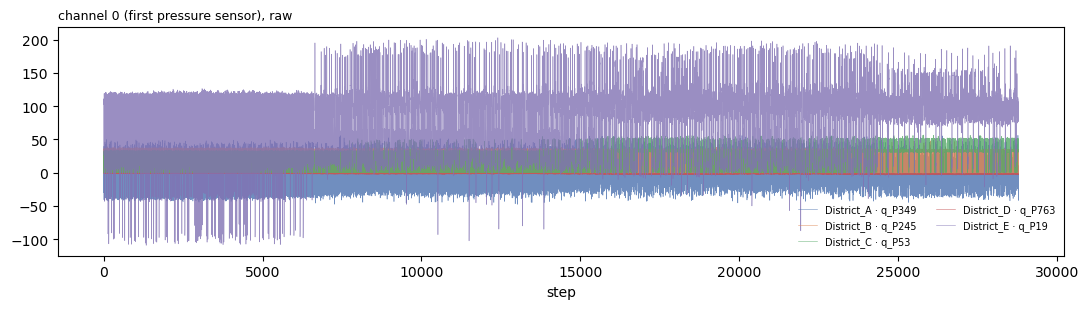

In [17]:
frames = D.client_frames(world, "manual")
print(f"channels per client: {D.assert_equal_channels(frames)}")

fig, ax = plt.subplots(figsize=(11, 3.2))
F.plot_client_series(ax, frames, channel=3)
ax.set_title("channel 0 (first pressure sensor), raw", fontsize=9, loc="left")
fig.tight_layout()
plt.show()

## 3. Ground truth — district land-use over time

The continuous share (left) and the discrete dominant-category letter it's thresholded to
(right, what `world.regimes()` returns) — read together, since a district can be moving
substantially (District_A's industrial share climbs steadily below) without its *dominant*
category ever flipping. `init`/`final` are shaded from `world.phases()`, derived from where
the realized dominant-category curve actually changes — not from a fixed warm-up assumption.

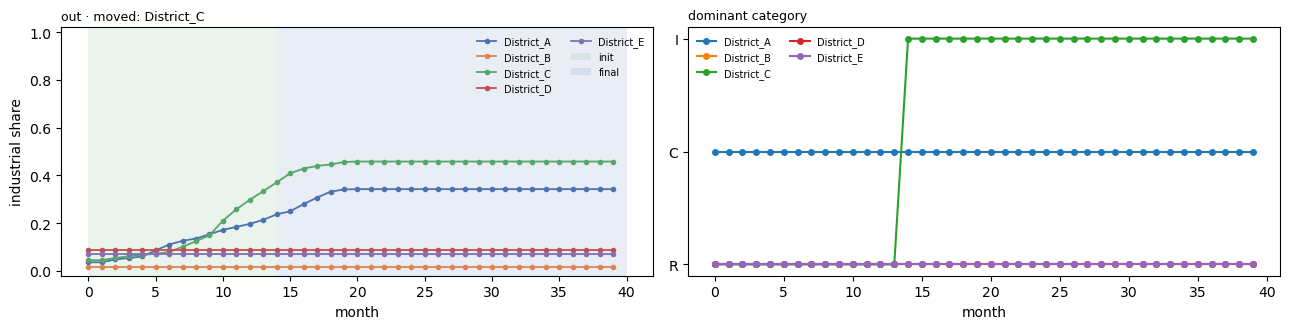

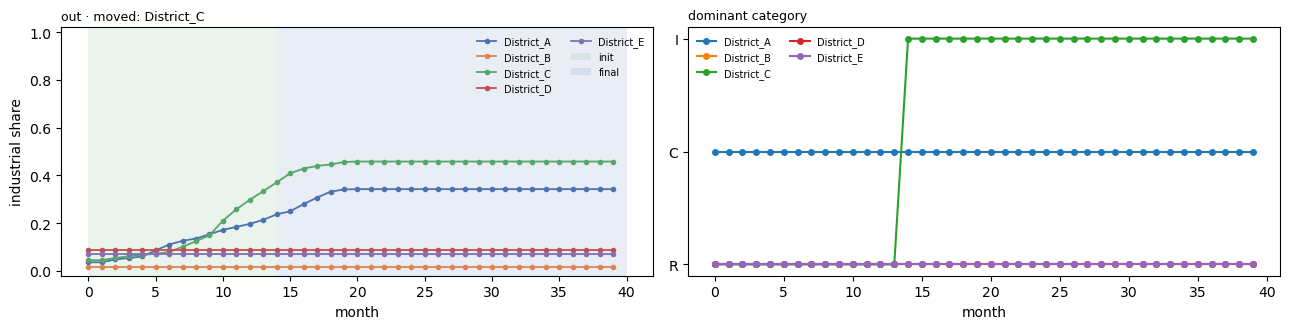

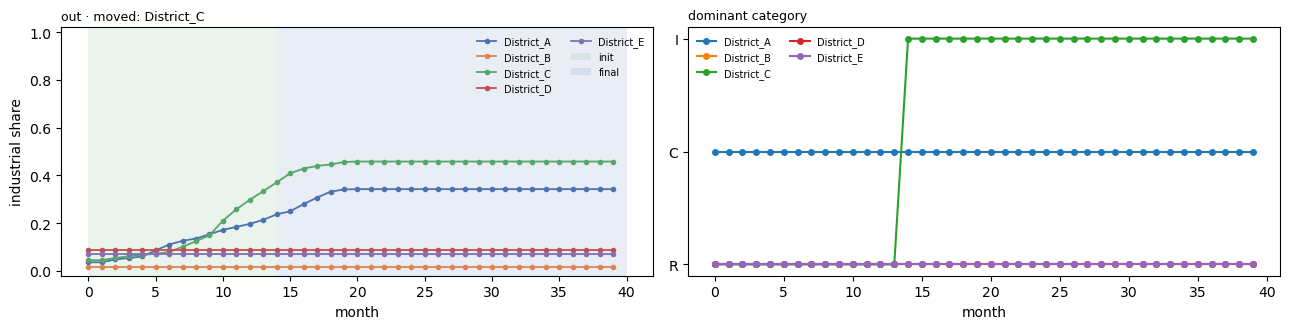

init  regime: {'District_A': 'C', 'District_B': 'R', 'District_C': 'R', 'District_D': 'R', 'District_E': 'R'}
final regime: {'District_A': 'C', 'District_B': 'R', 'District_C': 'I', 'District_D': 'R', 'District_E': 'R'}
moved: ['District_C']


In [20]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
plot_category_shares(ax[0], world, "industrial")
cat = world.category_table
for d, g in cat.groupby("district"):
    ax[1].plot(g["month"], g["dominant"].map({"R": 0, "C": 1, "I": 2}),
               marker="o", ms=4, label=d)
ax[1].set_yticks([0, 1, 2], ["R", "C", "I"])
ax[1].set_xlabel("month")
ax[1].set_title("dominant category", fontsize=9, loc="left")
ax[1].legend(fontsize=7, frameon=False, ncol=2)
fig.tight_layout()
plt.show()
print(f"init  regime: {world.regimes(phase='init')}")
print(f"final regime: {world.regimes(phase='final')}")
print(f"moved: {world.drifted_districts()}")

## 4. Train one cell

Same `CellSpec` / `run_cell` as the real pipeline. Window geometry is sized to this generator's
`resolution_h=1` and short horizon — widen `window_size`/lengthen `rounds` once you're working
with the full 40-month run rather than this 4-month toy.

In [7]:
spec = CellSpec(
    placement="manual", kinds=("pressure", "flow"),
    transform="none", scaling="minmax_ref",
    geometry=Geometry(interval_agg_h=1, window_size=24, step_size=4),
    model=ModelCfg(lstm_units=16), training=TrainCfg(rounds=5, fl_seed=0),
    cap=None, snapshot_rounds="sparse", snapshot_points=1500,
)

store = Store(REPO / "notebooks" / "0_prospection" / "simulation")
res = run_cell(world, spec, store=store, verbose=True)
res.setdefault("snapshots", res.get("latents_by_round"))
print(f"run_key {res['run_key']}  cache_hit={res['cache_hit']}  {res.get('seconds')}s")

  round   0  loss 0.23564  online 5
  round   1  loss 0.84892  online 5
  round   2  loss 0.80244  online 5
  round   3  loss 0.78770  online 5
  round   4  loss 0.76613  online 5
run_key 37178f58c9ab  cache_hit=False  38.6s


c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\0_prospection\simulation\store.py:196: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  reg = pd.concat([reg, pd.DataFrame([row])], ignore_index=True)


In [8]:
checks = M.check_run(res, world)
assert checks["passed"].all(), checks[~checks["passed"]]
checks

,check,value,passed
0,latent_dim,32,True
1,prototype_dim,32,True
2,latent_rows == windows,35390,True
3,latents_finite,True,True
4,prototypes_finite,True,True
5,proto_rows,1000,True
6,global_proto_rounds,5,True
7,clients_synced_after_fedavg,True,True
8,prototypes == eval-mode mean latent,0.0,True
9,snapshots have pre and post,"[post, pre]",True


## 5. Similarity

One `(scope, round, phase)` slice at a time, as always. `p_floor` here need not be 0.10/0.20 —
with land-use possibly splitting the 5 districts into three distinct groups instead of two
(R / C / I rather than a strict binary), the exhaustive label-shuffle null has more distinct
assignments and a lower floor; it's printed per row rather than assumed.

In [9]:
sim, clu = C.score_run(res, world, methods=("proto_cos", "proto_cos_dc"),
                       scopes=("local",), phases=("init", "final"))
store.save_scores("similarity", sim)
store.save_scores("clusters", clu)

(clu.drop_duplicates(["round", "phase", "method"])
    [["round", "phase", "method", "regime_gap", "gap_lift", "gap_p", "p_floor", "ari"]]
    .round(3))

,round,phase,method,regime_gap,gap_lift,gap_p,p_floor,ari
0,0,init,proto_cos,0.209,0.209,0.2,0.20,0.000
5,0,init,proto_cos_dc,0.207,0.207,0.2,0.20,0.231
10,0,final,proto_cos,-0.043,-0.043,0.7,0.05,-0.087
15,0,final,proto_cos_dc,-0.110,-0.110,0.9,0.05,-0.087
20,1,init,proto_cos,0.044,0.044,0.2,0.20,0.000
25,1,init,proto_cos_dc,0.238,0.238,0.2,0.20,0.231
30,1,final,proto_cos,0.019,0.019,0.2,0.05,-0.087
35,1,final,proto_cos_dc,-0.081,-0.081,0.6,0.05,-0.087
40,2,init,proto_cos,0.050,0.050,0.2,0.20,0.000
45,2,init,proto_cos_dc,0.032,0.032,0.4,0.20,-0.154


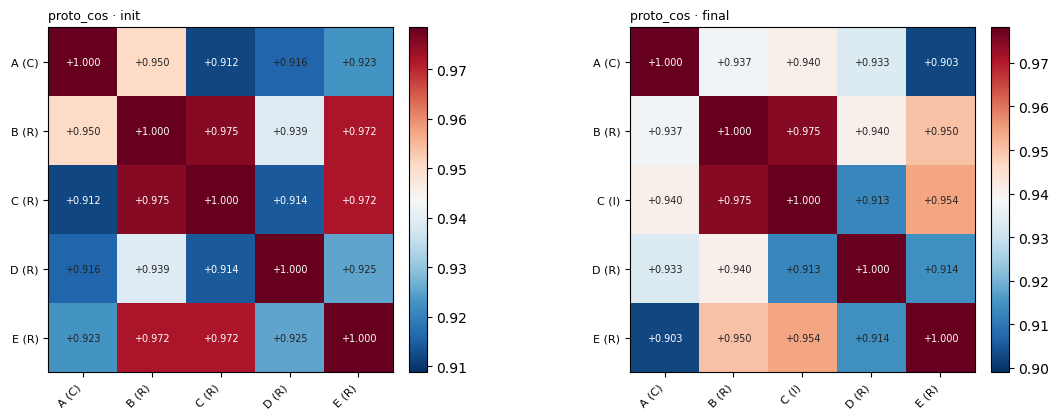

In [10]:
r_last = int(res["prototypes"][res["prototypes"]["scope"] == "local"]["round"].max())
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
for a, phase in zip(ax, ["init", "final"]):
    if world.phase_months(phase):
        S = C.similarity(res["prototypes"], world, "proto_cos", "local", r_last, phase)
        F.plot_similarity(a, S, world.regimes(phase=phase), title=f"proto_cos · {phase}")
    else:
        a.set_title(f"{phase}: no label-clean months", fontsize=9)
fig.tight_layout()

## 6. Latent space + interactive browser

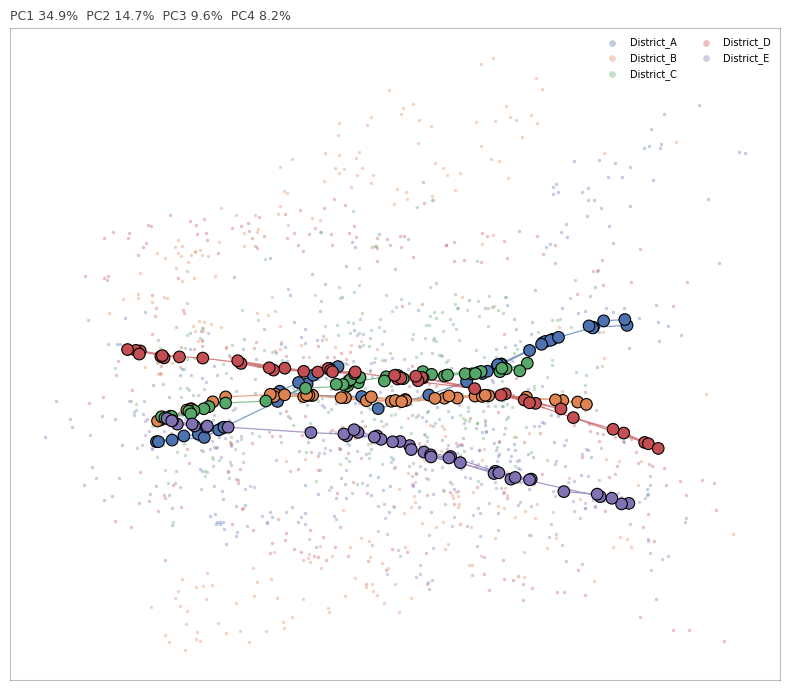

In [11]:
snaps, protos = res["snapshots"], res["prototypes"]
d = snaps[(snaps["round"] == r_last) & (snaps["stage"] == "pre")].reset_index(drop=True)
pr = protos[(protos["scope"] == "local") & (protos["round"] == r_last)].reset_index(drop=True)
Ep, Eq, sub = F.project(d[F.fcols(d)].to_numpy(), pr[F.fcols(pr)].to_numpy(), "PCA", 0, "windows")

fig, ax = plt.subplots(figsize=(8, 7))
F.plot_latent(ax, d, Ep, pr, Eq, colour_by="district", subtitle=sub, trajectory=True)
ax.legend(fontsize=7, frameon=False, markerscale=2, ncol=2)
fig.tight_layout()

In [ ]:
import widgets as WGT
_ = WGT.latent_browser(world, res)

In [14]:
_ = WGT.preprocessing_browser(world, spec, cache=D.CACHE)

TraitError: Invalid selection: value not found

## What this doesn't tell you yet

* **No `boundary`/`variance` placement.** Only the curated sensors above are usable — there's no
  topology in this drop to derive others from.
* **Only pressure + flow at the given nodes/links are validated**, not the district's full node
  set (`assignment.csv` has 32–131 nodes per district; the sensors above are a fixed 2+3, same
  as the real pipeline's curated placements — not "all of it").
* **Toy horizon.** This run is 4 months; a 40-month run will resolve `world.phases()` on real
  data instead of a 1-month init / 1-month final artifact of the toy's short horizon.
* **`drift_district` is `None` by design** (see the intro) — anything that reads a single mover
  (`metrics.drift_metrics`) degrades to `NaN` here rather than picking one arbitrarily.